In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        break
    break

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchmetrics
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms
from PIL import Image
import pandas as pd
import os

In [16]:
import matplotlib.pyplot as plt

## Download train, validation and test dataframes

In [17]:
train_id = "16ADiN0-geWlmkhN04bymFy_N7OA0SPHy"
train_url = f'https://drive.google.com/uc?id={train_id}'
# Load the CSV file into a pandas DataFrame
train_df = pd.read_csv(train_url)
train_df.head()

,File,Encoded_Label
0,n02437312/images/n02437312_229.JPEG,53
1,n02437312/images/n02437312_394.JPEG,53
2,n02437312/images/n02437312_15.JPEG,53
3,n02437312/images/n02437312_62.JPEG,53
4,n02437312/images/n02437312_17.JPEG,53


In [18]:
train_df["Encoded_Label"]

0         53
1         53
2         53
3         53
4         53
        ... 
99995    121
99996    121
99997    121
99998    121
99999    121
Name: Encoded_Label, Length: 100000, dtype: int64

In [19]:
val_id = "1lGkKcAD6Kc7JhfYsa9naVIwwc-MKdXQI"
val_url = f'https://drive.google.com/uc?id={val_id}'
# Load the CSV file into a pandas DataFrame
val_df = pd.read_csv(val_url)
val_df.head()

,File,Encoded_Label
0,val_4526.JPEG,115
1,val_7545.JPEG,88
2,val_1726.JPEG,149
3,val_4997.JPEG,99
4,val_6429.JPEG,149


In [20]:
test_id = "1lOi6xnfVghuzj1fYlIBbLNWWZQvahygQ"
test_url = f'https://drive.google.com/uc?id={test_id}'
# Load the CSV file into a pandas DataFrame
test_df = pd.read_csv(test_url)
test_df.head()

,File
0,val_9240.JPEG
1,val_9308.JPEG
2,val_3262.JPEG
3,val_3528.JPEG
4,val_4147.JPEG


In [21]:
class CSVImageDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df         = df
        self.images_dir = images_dir
        self.transform  = transform
        self.has_labels = "Encoded_Label" in self.df.columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row["File"])

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        if self.has_labels:
            return img, torch.tensor(row["Encoded_Label"], dtype=torch.long)
        return img


        return img, torch.tensor(label, dtype=torch.long)
    def __len__(self):
        return len(self.df)


In [22]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


# ── Datasets ──────────────────────────────────────────────────────────────────
TRAIN_DIR = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/"
VAL_DIR = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/val/images/"

train_dataset = CSVImageDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset   = CSVImageDataset(val_df,   VAL_DIR, transform=test_transform)
test_dataset  = CSVImageDataset(test_df,  VAL_DIR, transform=test_transform)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# ── Sanity check ──────────────────────────────────────────────────────────────
images, labels = next(iter(train_loader))
print(f"Batch shape : {images.shape}")   # [64, 3, 128, 128]
print(f"Labels shape: {labels.shape}")   # [64]
print(f"Unique labels in batch: {labels.unique()}")

Batch shape : torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])
Unique labels in batch: tensor([  2,   8,  10,  11,  13,  14,  23,  24,  26,  27,  34,  35,  40,  49,
         53,  57,  60,  70,  77,  80,  87,  89,  90,  91,  95,  98, 101, 102,
        103, 106, 111, 112, 113, 118, 119, 120, 121, 124, 128, 133, 139, 145,
        146, 152, 154, 156, 162, 163, 164, 169, 171, 176, 180, 184, 185, 186,
        189, 191, 193])


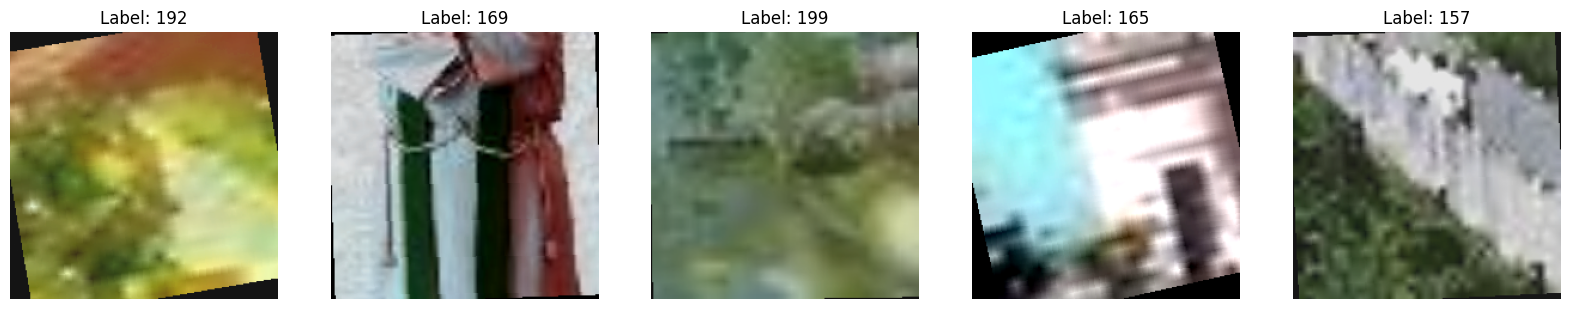

In [23]:
# Plotting the first few images in the batch
images, labels = next(iter(train_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

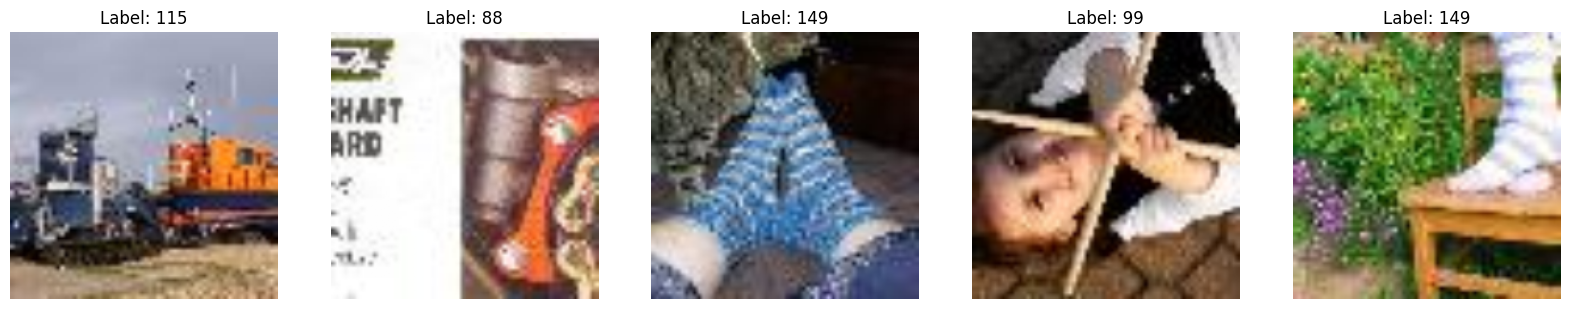

In [24]:
# Plotting the first few images in the batch
images, labels = next(iter(val_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

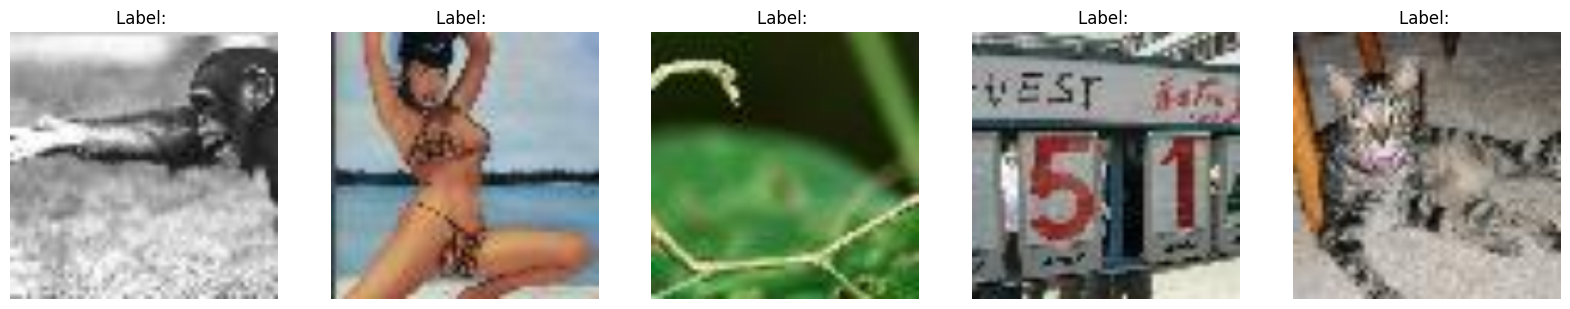

In [25]:
# Plotting the first few images in the batch
images = next(iter(test_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: ")
plt.show()

## Test Set — No Labels Available

 The test set does not include ground-truth labels. To evaluate your model
 on the test set, you need to:

 1. Run inference on the test loader to get predictions for each image
 2. Create a CSV with two columns: `File` (the image filename) and `Encoded_Label` (your predicted class)
 3. Submit that CSV for evaluation

 You can generate it like this:

 ```python
 import torch
 import pandas as pd

 model.eval()
 filenames   = test_dataset.df["File"].tolist()
 predictions = []

 with torch.inference_mode():
     for i, images in enumerate(test_loader):
         images  = images.to(device)
         logits  = model(images)
         preds   = logits.argmax(dim=1).cpu().tolist()
         predictions.extend(preds)

 submission = pd.DataFrame({"File": filenames, "Encoded_Label": predictions})
 submission.to_csv("submission.csv", index=False)
 print(submission.head())
 ```

 Make sure the order of `filenames` matches the order images are loaded
 by the test loader — since `shuffle=False`, the order is preserved.

# Importar modelo preentrenado

In [26]:

    
model = torch.hub.load("pytorch/vision", "efficientnet_b0", weights="EfficientNet_B0_Weights.IMAGENET1K_V1")
for param in model.features.parameters():
    param.requires_grad = False
    
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(1280, 200)
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

model.num_classes = 200

Using cache found in /root/.cache/torch/hub/pytorch_vision_main


In [27]:
model = model.to(device)

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

In [28]:
def train_one_epoch(model, loader, optimizer, criterion, acc_metric, device):
    model.train()
    acc_metric.reset()
    total_loss = 0.0

    for i, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device, non_blocking=True)
        images, labels = images.to(device), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        acc_metric.update(logits, labels)

    return total_loss / len(loader.dataset), acc_metric.compute().item()

In [29]:
def evaluate(model, loader, criterion, acc_metric, device):
    model.eval()
    acc_metric.reset()
    total_loss = 0.0

    with torch.inference_mode():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            total_loss += criterion(logits, labels).item() * labels.size(0)
            acc_metric.update(logits, labels)

    return total_loss / len(loader.dataset), acc_metric.compute().item()

In [30]:
torch.manual_seed(123)
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = model.to(device)

train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=200).to(device)
val_acc   = torchmetrics.Accuracy(task="multiclass", num_classes=200).to(device)

writer = SummaryWriter(log_dir="logs/resnet18-torchhub-cifar10")

dummy = torch.zeros(1, 3, 128, 128).to(device)
writer.add_graph(model, dummy)

In [31]:
MAX_EPOCHS = 50

def run_training_phase(model, optimizer, scheduler, epochs):
    for epoch in range(1, epochs):  # fase 1
    
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, train_acc, device
        )
    
        vl_loss, vl_acc = evaluate(
            model, val_loader, criterion, val_acc, device
        )
    
        writer.add_scalars("Loss",     {"train": tr_loss, "val": vl_loss}, epoch)
        writer.add_scalars("Accuracy", {"train": tr_acc,  "val": vl_acc},  epoch)
    
        scheduler.step()
    
        print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
              f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
              f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")
    writer.close()


In [32]:
def freeze_backbone(model):
    for param in model.features.parameters():
        param.requires_grad = False

def unfreeze_backbone(model):
    for param in model.features.parameters():
        param.requires_grad = True

In [33]:
next(model.parameters()).device

device(type='cuda', index=0)

In [34]:
#Fase 1
freeze_backbone(model)
run_training_phase(model, optimizer, scheduler, 5)
#Fase 2
unfreeze_backbone(model)
optimizer = torch.optim.AdamW([
    {"params": model.features.parameters(), "lr": 1e-5},
    {"params": model.classifier.parameters(), "lr": 1e-4}
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15
)
run_training_phase(model, optimizer, scheduler, 15)

Epoch 01/50 | Train Loss: 4.6219  Acc: 0.1435 | Val Loss: 3.7142  Acc: 0.3862
Epoch 02/50 | Train Loss: 4.1053  Acc: 0.2148 | Val Loss: 3.2353  Acc: 0.4508
Epoch 03/50 | Train Loss: 3.9614  Acc: 0.2365 | Val Loss: 3.0360  Acc: 0.4840
Epoch 04/50 | Train Loss: 3.9018  Acc: 0.2450 | Val Loss: 2.9632  Acc: 0.4887
Epoch 01/50 | Train Loss: 3.3918  Acc: 0.3512 | Val Loss: 2.1656  Acc: 0.6437
Epoch 02/50 | Train Loss: 3.0049  Acc: 0.4362 | Val Loss: 1.9716  Acc: 0.6950
Epoch 03/50 | Train Loss: 2.8425  Acc: 0.4731 | Val Loss: 1.8701  Acc: 0.7197
Epoch 04/50 | Train Loss: 2.7241  Acc: 0.5024 | Val Loss: 1.8041  Acc: 0.7410
Epoch 05/50 | Train Loss: 2.6517  Acc: 0.5191 | Val Loss: 1.7600  Acc: 0.7513
Epoch 06/50 | Train Loss: 2.6038  Acc: 0.5298 | Val Loss: 1.7356  Acc: 0.7582
Epoch 07/50 | Train Loss: 2.5644  Acc: 0.5397 | Val Loss: 1.7222  Acc: 0.7603
Epoch 08/50 | Train Loss: 2.5335  Acc: 0.5471 | Val Loss: 1.6991  Acc: 0.7665
Epoch 09/50 | Train Loss: 2.5129  Acc: 0.5533 | Val Loss: 1.6915